# Archetypal Analysis

## Introduction

In this vignette, we present

1) a brief overview of the theory behind archetypal analysis
2) a description of the optimization procedure used in our implementation
3) a guide to using the `AA` class and its `AA.fit()` method

### Mathematical Setup (Notation and Objective)

We use the same notation as in the supplementary methods:

- $N$: number of samples (cells), $D$: embedding dimensions, $K$: number of archetypes
- $\mathbf{X} \in \mathbb{R}^{N \times D}$: data matrix (row $n$ is $\mathbf{x}_n^T$)
- $\mathbf{A} \in \mathbb{R}^{N \times K}$: sample-to-archetype coefficients
- $\mathbf{B} \in \mathbb{R}^{K \times N}$: archetype-to-sample coefficients
- $\mathbf{Z} \in \mathbb{R}^{K \times D}$: archetype matrix

Archetypal analysis assumes

$$
\hat{\mathbf{X}} = \mathbf{A}\mathbf{Z}, \qquad \mathbf{Z} = \mathbf{B}\mathbf{X}.
$$

With row-stochastic constraints,

$$
F(n,m) := \{\mathbf{H} \in \mathbb{R}^{n \times m} \mid \mathbf{H} \ge 0,\; \mathbf{H}\mathbf{1}_m = \mathbf{1}_n\},
$$

the optimization problem is

$$
\hat{\mathbf{A}}, \hat{\mathbf{B}}
= \arg\min_{\mathbf{A} \in F(N,K),\; \mathbf{B} \in F(K,N)}
\left\|\mathbf{X} - \mathbf{A}\mathbf{B}\mathbf{X}\right\|_F^2.
$$

Important properties used below: the objective is translation/scale invariant in $\mathbf{X}$ and biconvex in $(\mathbf{A},\mathbf{B})$.


First, we will import some package that we need throughout this vignette.

In [1]:
from datetime import datetime
import partipy as pt
import numpy as np
import matplotlib.pyplot as plt

Now, we simulate a dataset to provide an intuitive explanation of archetypal analysis. To make the simulation more realistic, we add noise to each data point by sampling a noise vector from an isotropic Gaussian distribution.

In [ ]:
X, A, Z = pt.simulate_archetypes(n_samples=1_000, n_archetypes=3, n_dimensions=2,
                                 noise_std=0.10, seed=123)
print(f"{X.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(1000, 2)
(1000, 3)
(3, 2)


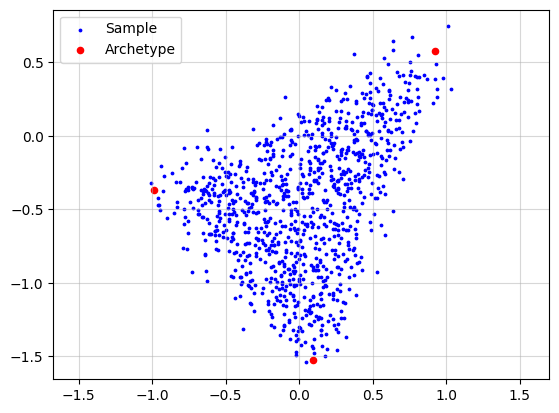

In [3]:
plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

## Standard Archetypal Analysis

For standard archetypal analysis, we solve

$$
\hat{\mathbf{A}}, \hat{\mathbf{B}}
= \arg\min_{\mathbf{A} \in F(N,K),\; \mathbf{B} \in F(K,N)}
\left\|\mathbf{X} - \mathbf{A}\mathbf{B}\mathbf{X}\right\|_F^2
$$

with alternating updates:

$$
\mathbf{A} \leftarrow \arg\min_{\mathbf{A} \in F(N,K)} \|\mathbf{X}-\mathbf{A}\mathbf{Z}\|_F^2,
\qquad
\mathbf{B} \leftarrow \arg\min_{\mathbf{B} \in F(K,N)} \|\mathbf{X}-\mathbf{A}\mathbf{B}\mathbf{X}\|_F^2,
\qquad
\mathbf{Z}=\mathbf{B}\mathbf{X}.
$$

In this notebook, `pt.AA(...)` executes this procedure (with solver-specific updates under simplex constraints).


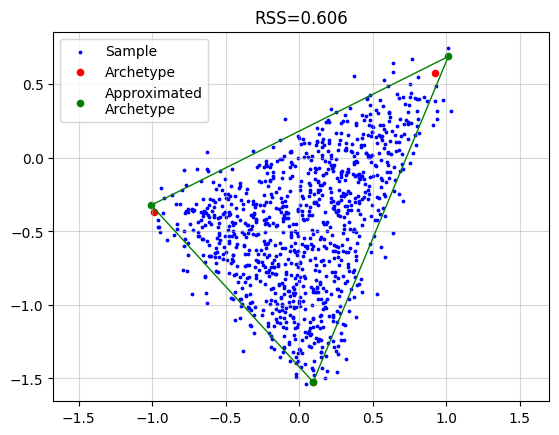

In [4]:
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

## Relaxation of Convex Constraint on Archetypes

With `delta > 0`, ParTIpy relaxes the strict convex-hull constraint on archetypes. A convenient formulation is

$$
\min_{\mathbf{A} \in F(N,K),\; \mathbf{B} \in F(K,N),\; \boldsymbol{\alpha} \in [1-\delta,1+\delta]^K}
\left\|\mathbf{X} - \mathbf{A}\,\operatorname{diag}(\boldsymbol{\alpha})\,\mathbf{B}\mathbf{X}\right\|_F^2,
$$

with archetypes

$$
\mathbf{Z} = \operatorname{diag}(\boldsymbol{\alpha})\,\mathbf{B}\mathbf{X}.
$$

Setting $\delta=0$ recovers standard archetypal analysis. This relaxation follows the formulation introduced in {cite:p}`morupArchetypalAnalysisMachine2012` and has been used in downstream ParTI applications {cite:p}`Korem2015`.


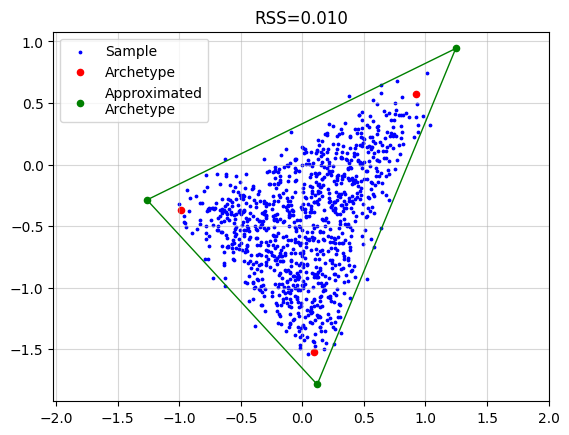

In [5]:
AA_object = pt.AA(n_archetypes=3, delta=0.25)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

## Robust Archetypal Analysis

ParTIpy's robust mode uses an **iterative reweighting** scheme (IRLS-like), following robust archetypal analysis ideas from {cite:p}`eugsterWeightedRobustArchetypal2011`. In iteration $t$, with sample weights $\mathbf{w}^{(t)}$ and $\mathbf{W}^{(t)}=\operatorname{diag}(\mathbf{w}^{(t)})$, the implemented updates are:

$$
\mathbf{A}^{(t+1)}
\leftarrow
\arg\min_{\mathbf{A}\in F(N,K)}
\left\|\mathbf{W}^{(t)}\mathbf{X} - \mathbf{A}\mathbf{Z}^{(t)}\right\|_F^2,
$$

$$
\mathbf{B}^{(t+1)}
\leftarrow
\arg\min_{\mathbf{B}\in F(K,N)}
\left\|\mathbf{X} - \mathbf{A}^{(t+1)}\mathbf{B}\,\mathbf{W}^{(t)}\mathbf{X}\right\|_F^2,
\qquad
\mathbf{Z}^{(t+1)} = \mathbf{B}^{(t+1)}\mathbf{W}^{(t)}\mathbf{X}.
$$

Then residuals are recomputed on the original scale,

$$
\mathbf{A}_0^{(t+1)}\leftarrow\arg\min_{\mathbf{A}\in F(N,K)}\left\|\mathbf{X}-\mathbf{A}\mathbf{Z}^{(t+1)}\right\|_F^2,
\qquad
\mathbf{R}^{(t+1)} = \mathbf{X}-\mathbf{A}_0^{(t+1)}\mathbf{Z}^{(t+1)},
$$

and weights are updated as $\mathbf{w}^{(t+1)} = \omega(\mathbf{R}^{(t+1)})$ (e.g. `bisquare`, `huber`).

In the `bisquare` option below, strong outliers are down-weighted toward zero.

To demonstrate this behavior, we now add synthetic outliers.


In [6]:
n_outliers = 5
outlier_mean = np.array([-1.0, 1.5])
X_wo = np.zeros((X.shape[0]+n_outliers, X.shape[1]))
X_wo[:X.shape[0], :] = X.copy()
rng = np.random.default_rng(seed=42)
X_wo[X.shape[0]:, :] = rng.normal(loc=outlier_mean, scale=(0.1, 0.1), size=(n_outliers, 2))

print(f"{X_wo.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(1005, 2)
(1000, 3)
(3, 2)


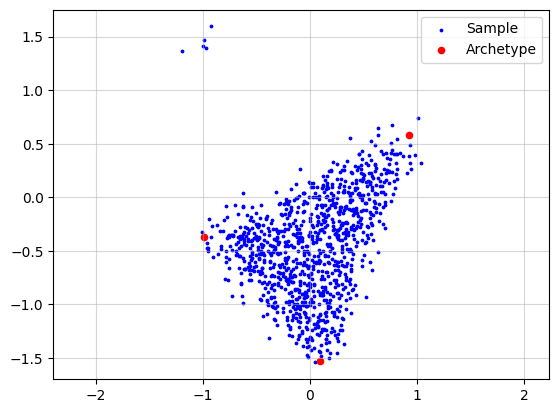

In [7]:
plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

Now if we just run the standard algorithm we obtain.

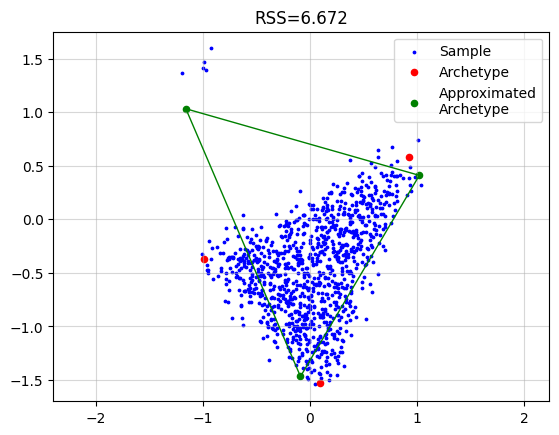

In [8]:
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X_wo)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

However, if we use the robust implementation we get a much better result. In the plot we colored each sample by the final weight. We see that the outlier samples have zero weight.

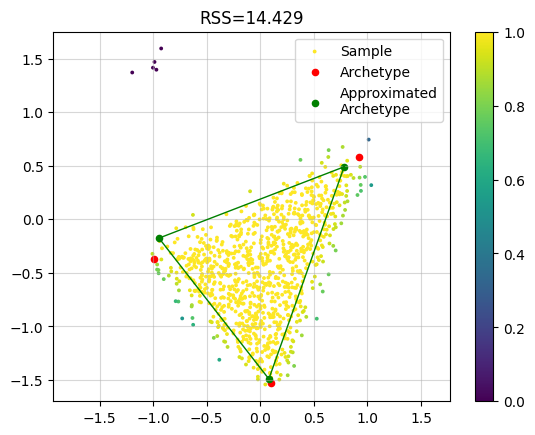

In [9]:
AA_object = pt.AA(n_archetypes=3, weight="bisquare", early_stopping=False)
AA_object.fit(X_wo)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c=AA_object.W, label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.colorbar()
plt.axis("equal")
plt.show()

## Coresets

For large $N$, we can optimize on a weighted subset (coreset) $\tilde{\mathbf{X}} \in \mathbb{R}^{\tilde{N} \times D}$ with $\tilde{N} \ll N$:

$$
\hat{\mathbf{A}}, \hat{\mathbf{B}}
= \arg\min_{\mathbf{A} \in F(\tilde{N},K),\; \mathbf{B} \in F(K,\tilde{N})}
\left\|\mathbf{W}\tilde{\mathbf{X}} - \mathbf{W}\mathbf{A}\mathbf{B}\tilde{\mathbf{X}}\right\|_F^2,
$$

where $\mathbf{W}$ is diagonal. In the current implementation, its diagonal entries are the **square roots** of coreset weights.

After convergence on the coreset, $\mathbf{A}$ is recomputed on the full dataset with fixed $\mathbf{Z}=\mathbf{B}\tilde{\mathbf{X}}$. This follows the AA coreset construction in {cite:p}`mairCoresetsArchetypalAnalysis2019`, which adapts lightweight coreset ideas from {cite:p}`bachemScalableMeansClustering2018`.


Let's use the same underlying archetypes but generate many more samples to illustrate the computational effect.


In [10]:
X, A, Z = pt.simulate_archetypes(n_samples=200_000, n_archetypes=3, n_dimensions=2, 
                                 noise_std=0.10, seed=123)
print(f"{X.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(200000, 2)
(200000, 3)
(3, 2)


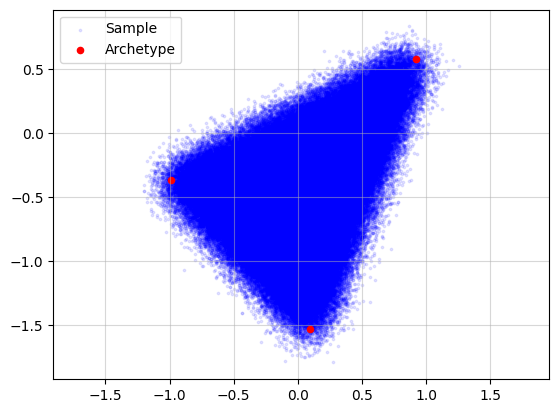

In [11]:
plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample", alpha=0.1)
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

Running archetypal analysis now takes quite some time

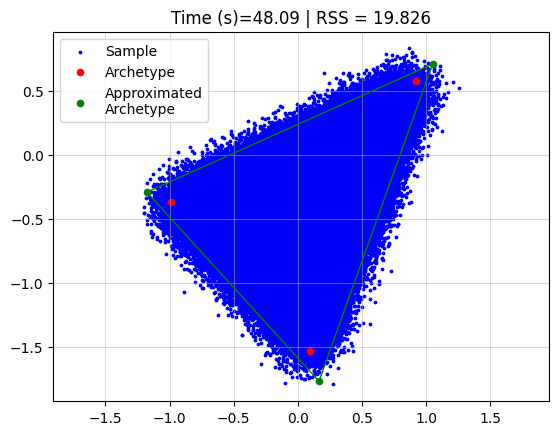

In [12]:
start = datetime.now()
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X)
Z_hat = AA_object.Z
end = datetime.now()
time = (end - start).total_seconds()

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"Time (s)={time:.2f} | RSS = {AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

However, if we use coresets we can drastically reduce the time, without affecting the reconstruction a lot.

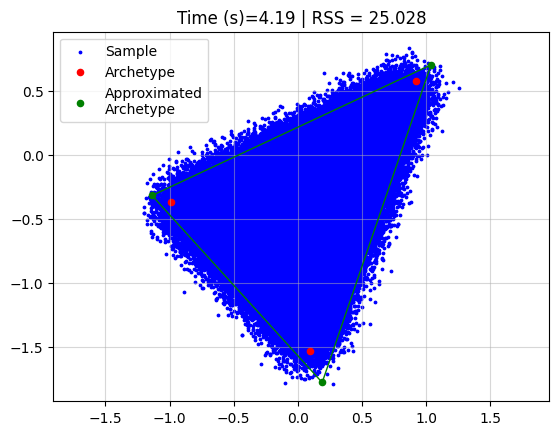

In [13]:
start = datetime.now()
AA_object = pt.AA(n_archetypes=3, coreset_algorithm="standard", coreset_fraction=0.05)
AA_object.fit(X)
Z_hat = AA_object.Z
end = datetime.now()
time = (end - start).total_seconds()

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"Time (s)={time:.2f} | RSS = {AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()